# Phase 5: Feature Importance and Interpretability

This phase focuses on identifying the most influential features affecting energy consumption using Random Forest feature importance and SHAP analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Data-Driven-Energy-Project')

Mounted at /content/drive


In [3]:
df = pd.read_csv("data/energy_efficiency.csv", encoding='latin1')

df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Distribution",
    "Heating_Load",
    "Cooling_Load"
]
df = df.dropna()

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = df["Heating_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

RANDOM FOREST FEATURE IMPORTANCE

TRAIN RANDOM FOREST

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
importances = rf.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
0,Relative_Compactness,0.394669
1,Surface_Area,0.192841
4,Height,0.150991
3,Roof_Area,0.135369
6,Glazing_Area,0.079723
2,Wall_Area,0.033833
7,Glazing_Distribution,0.011837
5,Orientation,0.000737


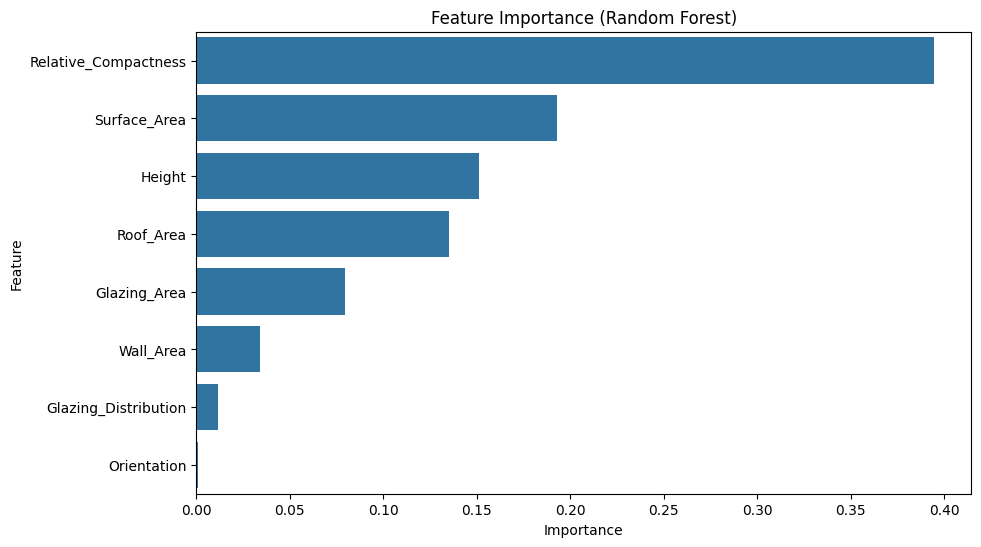

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)

plt.title("Feature Importance (Random Forest)")
plt.savefig("outputs/graphs/10_rf_feature_importance.png")

plt.show()

 SHAP ANALYSIS

In [8]:
!pip install shap

In [9]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

SHAP SUMMARY PLOT

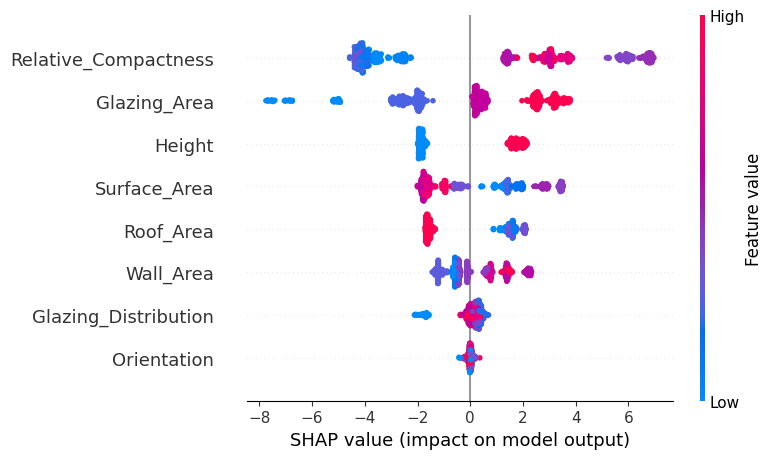

In [10]:
shap.summary_plot(shap_values, X)

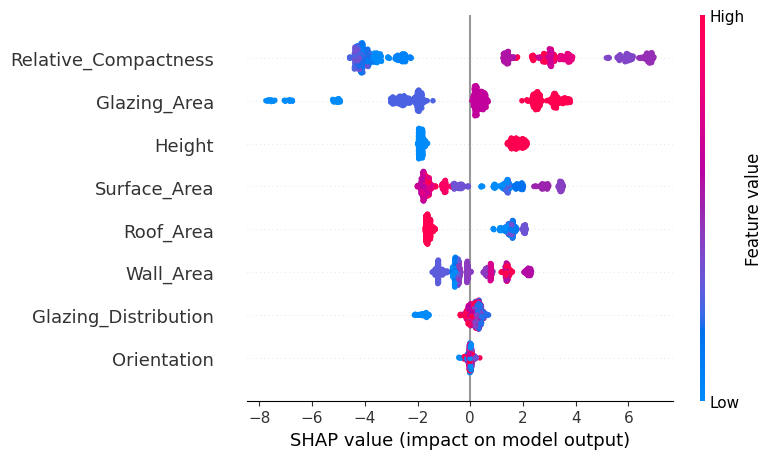

In [11]:
shap.summary_plot(shap_values, X, show=False)
plt.savefig("outputs/graphs/11_shap_summary.png")
plt.show()